# 03 — تجهيز بيانات Online Retail

يوثق هذا Notebook مصدر البيانات، التدقيق، سياسة التنظيف، إعادة بناء المعاملات، اختيار النطاق، والتخزين المتناثر. يستدعي المنطق القابل لإعادة الاستخدام من `src/data` ولا يطبق FP-Growth أو Apriori ولا يولد قواعد ارتباط.

## 1. التحقق من البيئة والمسارات

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display
from scipy import sparse

from src.data.paths import PROJECT_ROOT, project_path
from src.data.pipeline import run_pipeline
from src.data.raw_loader import verify_workbook_integrity

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
print(f"Python executable: {sys.executable}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw checksum: {verify_workbook_integrity()}")

Python executable: D:\University\Data Mining\smartbasket-fpgrowth-lab\.venv\Scripts\python.exe
Project root: D:\University\Data Mining\smartbasket-fpgrowth-lab
Raw checksum: 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d


## 2. أصل البيانات (Provenance)

In [2]:
metadata = json.loads(
    project_path("data", "raw", "online_retail", "source_metadata.json").read_text(encoding="utf-8")
)
pd.DataFrame(
    {
        "field": ["dataset_name", "publisher", "contributor", "license", "retrieval_date", "official_doi"],
        "value": [metadata[key] for key in ["dataset_name", "publisher", "contributor", "license", "retrieval_date", "official_doi"]],
    }
)

,field,value
0,dataset_name,Online Retail
1,publisher,UCI Machine Learning Repository
2,contributor,Daqing Chen
3,license,Creative Commons Attribution 4.0 International...
4,retrieval_date,2026-07-13
5,official_doi,https://doi.org/10.24432/C5BW33


## 3. تنفيذ خط التجهيز القابل لإعادة الإنتاج

تعيد الدالة التالية التحقق من checksum، وتقرأ workbook، وتولد تدقيق raw، وتطبق السياسة، وتفصل accepted/rejected، وتعيد بناء المعاملات، وتقارن النطاقات، وتحفظ CSR matrix والرسوم. لا يوجد منطق تعدين داخلها.

In [3]:
pipeline_summary = run_pipeline()
pipeline_summary

PipelineSummary(raw_rows=541909, valid_line_items=522447, rejected_records=19462, transactions=19773, unique_products=3797, core_scope='United Kingdom', core_transactions=17901, basket_rows=17901, basket_columns=3791, basket_nonzero=473636, workbook_sha256='43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d')

## 4. المخطط الخام ومشكلات الجودة

In [4]:
raw_schema = pd.read_csv(project_path("outputs", "tables", "raw_schema.csv"))
raw_missing = pd.read_csv(project_path("outputs", "tables", "raw_missing_values.csv"))
raw_quality = pd.read_csv(project_path("outputs", "tables", "raw_quality_summary.csv"))
display(raw_schema)
display(raw_missing)
display(raw_quality)

,column_name,dtype,non_null_count,missing_count,missing_percentage,unique_non_null,memory_bytes
0,InvoiceNo,string,541909,0,0.000000,25900,34149558
1,StockCode,string,541909,0,0.000000,4070,33645420
2,Description,string,540455,1454,0.268311,4223,45299523
3,Quantity,int64,541909,0,0.000000,722,4335272
4,InvoiceDate,datetime64[us],541909,0,0.000000,23260,4335272
5,UnitPrice,float64,541909,0,0.000000,1630,4335272
6,CustomerID,string,406829,135080,24.926694,4372,33868518
7,Country,string,541909,0,0.000000,38,38137498


,column_name,missing_count,missing_percentage
0,InvoiceNo,0,0.000000
1,StockCode,0,0.000000
2,Description,1454,0.268311
3,Quantity,0,0.000000
4,InvoiceDate,0,0.000000
5,UnitPrice,0,0.000000
6,CustomerID,135080,24.926694
7,Country,0,0.000000


,metric,value,notes
0,raw_rows,541909,NaN
1,raw_columns,8,NaN
2,raw_memory_bytes,198106465,NaN
3,duplicate_full_rows,10147,All rows participating in a duplicate group.
4,duplicate_rows_beyond_first,5268,Rows removable when retaining the first exact ...
5,unique_invoices,25900,NaN
6,unique_stock_codes,4070,NaN
7,unique_descriptions,4223,NaN
8,unique_customers,4372,NaN
9,unique_countries,38,NaN


## 5. سياسة التنظيف

توجد السياسة الكاملة في `docs/notes/DATA_CLEANING_POLICY.md`. أهم مبادئها: raw immutable، الإلغاء بحسب `InvoiceNo` الذي يبدأ بـ `C`، فصل الكمية والسعر غير الموجبين، عدم تخمين الوصف، قبول غياب `CustomerID` لتحليل السلة، تصنيف الخدمات بأكواد مرصودة فقط، وتدقيق النسخ الكاملة الزائدة.

## 6. Data Lineage والسجلات المفصولة

In [5]:
lineage = pd.read_csv(project_path("outputs", "tables", "data_cleaning_lineage.csv"))
rejections = pd.read_csv(project_path("outputs", "tables", "cleaning_rejection_reasons.csv"))
assert lineage.iloc[-1]["output_record_count"] == pipeline_summary.valid_line_items
assert lineage["removed_or_separated_count"].sum() == pipeline_summary.rejected_records
display(lineage)
display(rejections)

,step_name,input_record_count,removed_or_separated_count,output_record_count,percentage_affected,reason,policy_reference
0,missing_invoice,541909,0,541909,0.000000,Missing invoice identifier,DATA_CLEANING_POLICY.md — Missing invoice iden...
1,cancelled_invoice,541909,9288,532621,1.713941,Cancelled invoice,DATA_CLEANING_POLICY.md — Cancelled invoices
2,invalid_quantity,532621,1336,531285,0.250835,Missing or non-positive quantity,DATA_CLEANING_POLICY.md — Invalid quantities
3,invalid_price,531285,1181,530104,0.222291,Missing or non-positive unit price,DATA_CLEANING_POLICY.md — Invalid prices
4,missing_description,530104,0,530104,0.000000,Missing product description,DATA_CLEANING_POLICY.md — Missing product desc...
5,non_product_line,530104,2436,527668,0.459532,Observed administrative or non-product code,DATA_CLEANING_POLICY.md — Administrative lines
6,duplicate_full_row,527668,5221,522447,0.989448,Exact duplicate beyond first occurrence,DATA_CLEANING_POLICY.md — Duplicate records


,reason,explanation,all_flagged_record_count,primary_sequential_record_count,percentage_of_raw_records_primary,percentage_of_rejected_records_primary
0,missing_invoice,Missing invoice identifier,0,0,0.000000,0.000000
1,cancelled_invoice,Cancelled invoice,9288,9288,1.713941,47.723769
2,invalid_quantity,Missing or non-positive quantity,10624,1336,0.246536,6.864659
3,invalid_price,Missing or non-positive unit price,2517,1181,0.217933,6.068236
4,missing_description,Missing product description,1454,0,0.000000,0.000000
5,non_product_line,Observed administrative or non-product code,3044,2436,0.449522,12.516699
6,duplicate_full_row,Exact duplicate beyond first occurrence,5268,5221,0.963446,26.826637


## 7. إعادة بناء المعاملات وإحصاءات حجم السلة

In [6]:
processed_summary = pd.read_csv(project_path("outputs", "tables", "processed_dataset_summary.csv"))
basket_sizes = pd.read_csv(project_path("outputs", "tables", "transaction_size_summary.csv"))
display(processed_summary)
display(basket_sizes)

,metric,value
0,workbook_sheet_names,Online Retail
1,raw_line_items,541909
2,valid_line_items,522447
3,rejected_or_separated_line_items,19462
4,valid_transactions_all_countries,19773
5,unique_products_all_countries,3797
6,core_scope,United Kingdom
7,core_transactions,17901
8,core_unique_products,3791
9,basket_matrix_rows,17901


,statistic,value
0,count,17901.000000
1,mean,26.458634
2,std,48.864825
3,min,1.000000
4,25%,6.000000
5,50%,15.000000
6,75%,29.000000
7,90%,53.000000
8,95%,77.000000
9,99%,230.000000


## 8. مقارنة البلدان واختيار Core Scope

In [7]:
country_summary = pd.read_csv(project_path("outputs", "tables", "country_summary.csv"))
scope_table = pd.read_csv(project_path("outputs", "tables", "scope_comparison.csv"))
display(scope_table)
display(country_summary.head(10))
selected = scope_table.loc[scope_table["scope"].eq(pipeline_summary.core_scope)].iloc[0]
print(
    f"Selected scope: {selected['scope']} — "
    f"{int(selected['transaction_count']):,} transactions, "
    f"{selected['transaction_share_percentage']:.2f}% of valid transactions."
)

,scope,transaction_count,unique_products,median_basket_size,mean_basket_size,first_invoice_date,last_invoice_date,transaction_share_percentage,expected_basket_matrix_width,interpretability_implication
0,All countries,19773,3797,15.0,26.156729,2010-12-01 08:26:00,2011-12-09 12:50:00,100.000000,3797,Multiple national markets and possible assortm...
1,United Kingdom,17901,3791,15.0,26.458634,2010-12-01 08:26:00,2011-12-09 12:49:00,90.532544,3791,Single dominant market context with more consi...


,Country,transaction_count,median_basket_size,mean_basket_size,first_invoice_date,last_invoice_date,unique_products,transaction_share_percentage
0,United Kingdom,17901,15.0,26.458634,2010-12-01 08:26:00,2011-12-09 12:49:00,3791,90.532544
1,Germany,443,14.0,19.487585,2010-12-01 13:04:00,2011-12-09 12:16:00,1662,2.240429
2,France,382,17.0,21.109948,2010-12-01 08:45:00,2011-12-09 12:50:00,1538,1.931927
3,EIRE,282,22.5,27.531915,2010-12-01 14:05:00,2011-12-08 15:54:00,1965,1.426187
4,Belgium,98,18.0,19.744898,2010-12-03 16:35:00,2011-12-09 10:10:00,776,0.495625
5,Netherlands,93,13.0,24.967742,2010-12-01 11:27:00,2011-12-08 12:12:00,781,0.470338
6,Spain,88,21.0,27.284091,2010-12-03 12:20:00,2011-12-07 17:05:00,1090,0.445051
7,Australia,56,10.0,21.053571,2010-12-01 10:03:00,2011-11-24 12:30:00,598,0.283214
8,Portugal,50,21.0,28.800000,2010-12-03 15:14:00,2011-12-07 15:56:00,704,0.252870
9,Switzerland,50,25.0,38.280000,2010-12-03 10:36:00,2011-11-29 08:40:00,977,0.252870


Selected scope: United Kingdom — 17,901 transactions, 90.53% of valid transactions.


اختيرت المملكة المتحدة لأنها السوق المهيمنة وتحتفظ بأكثر من 90% من المعاملات الصالحة، مع سياق سوق أكثر اتساقاً وعرض مصفوفة قريب من النطاق الكامل. بقي جدول جميع البلدان محفوظاً للمقارنة ولم يُحذف.

## 9. Basket Matrix والتخزين المتناثر

In [8]:
matrix = sparse.load_npz(project_path("data", "processed", "online_retail_basket_matrix.npz"))
column_metadata = json.loads(
    project_path("data", "processed", "online_retail_basket_columns.json").read_text(encoding="utf-8")
)
assert matrix.shape == tuple(column_metadata["shape"])
assert set(matrix.data.tolist()) <= {1}
print(f"CSR shape: {matrix.shape}")
print(f"Nonzero entries: {matrix.nnz:,}")
print(f"Density: {matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.6%}")
print("The matrix is binary and stored as compressed SciPy CSR data.")

CSR shape: (17901, 3791)
Nonzero entries: 473,636
Density: 0.697933%
The matrix is binary and stored as compressed SciPy CSR data.


## 10. رسوم استكشافية مختارة

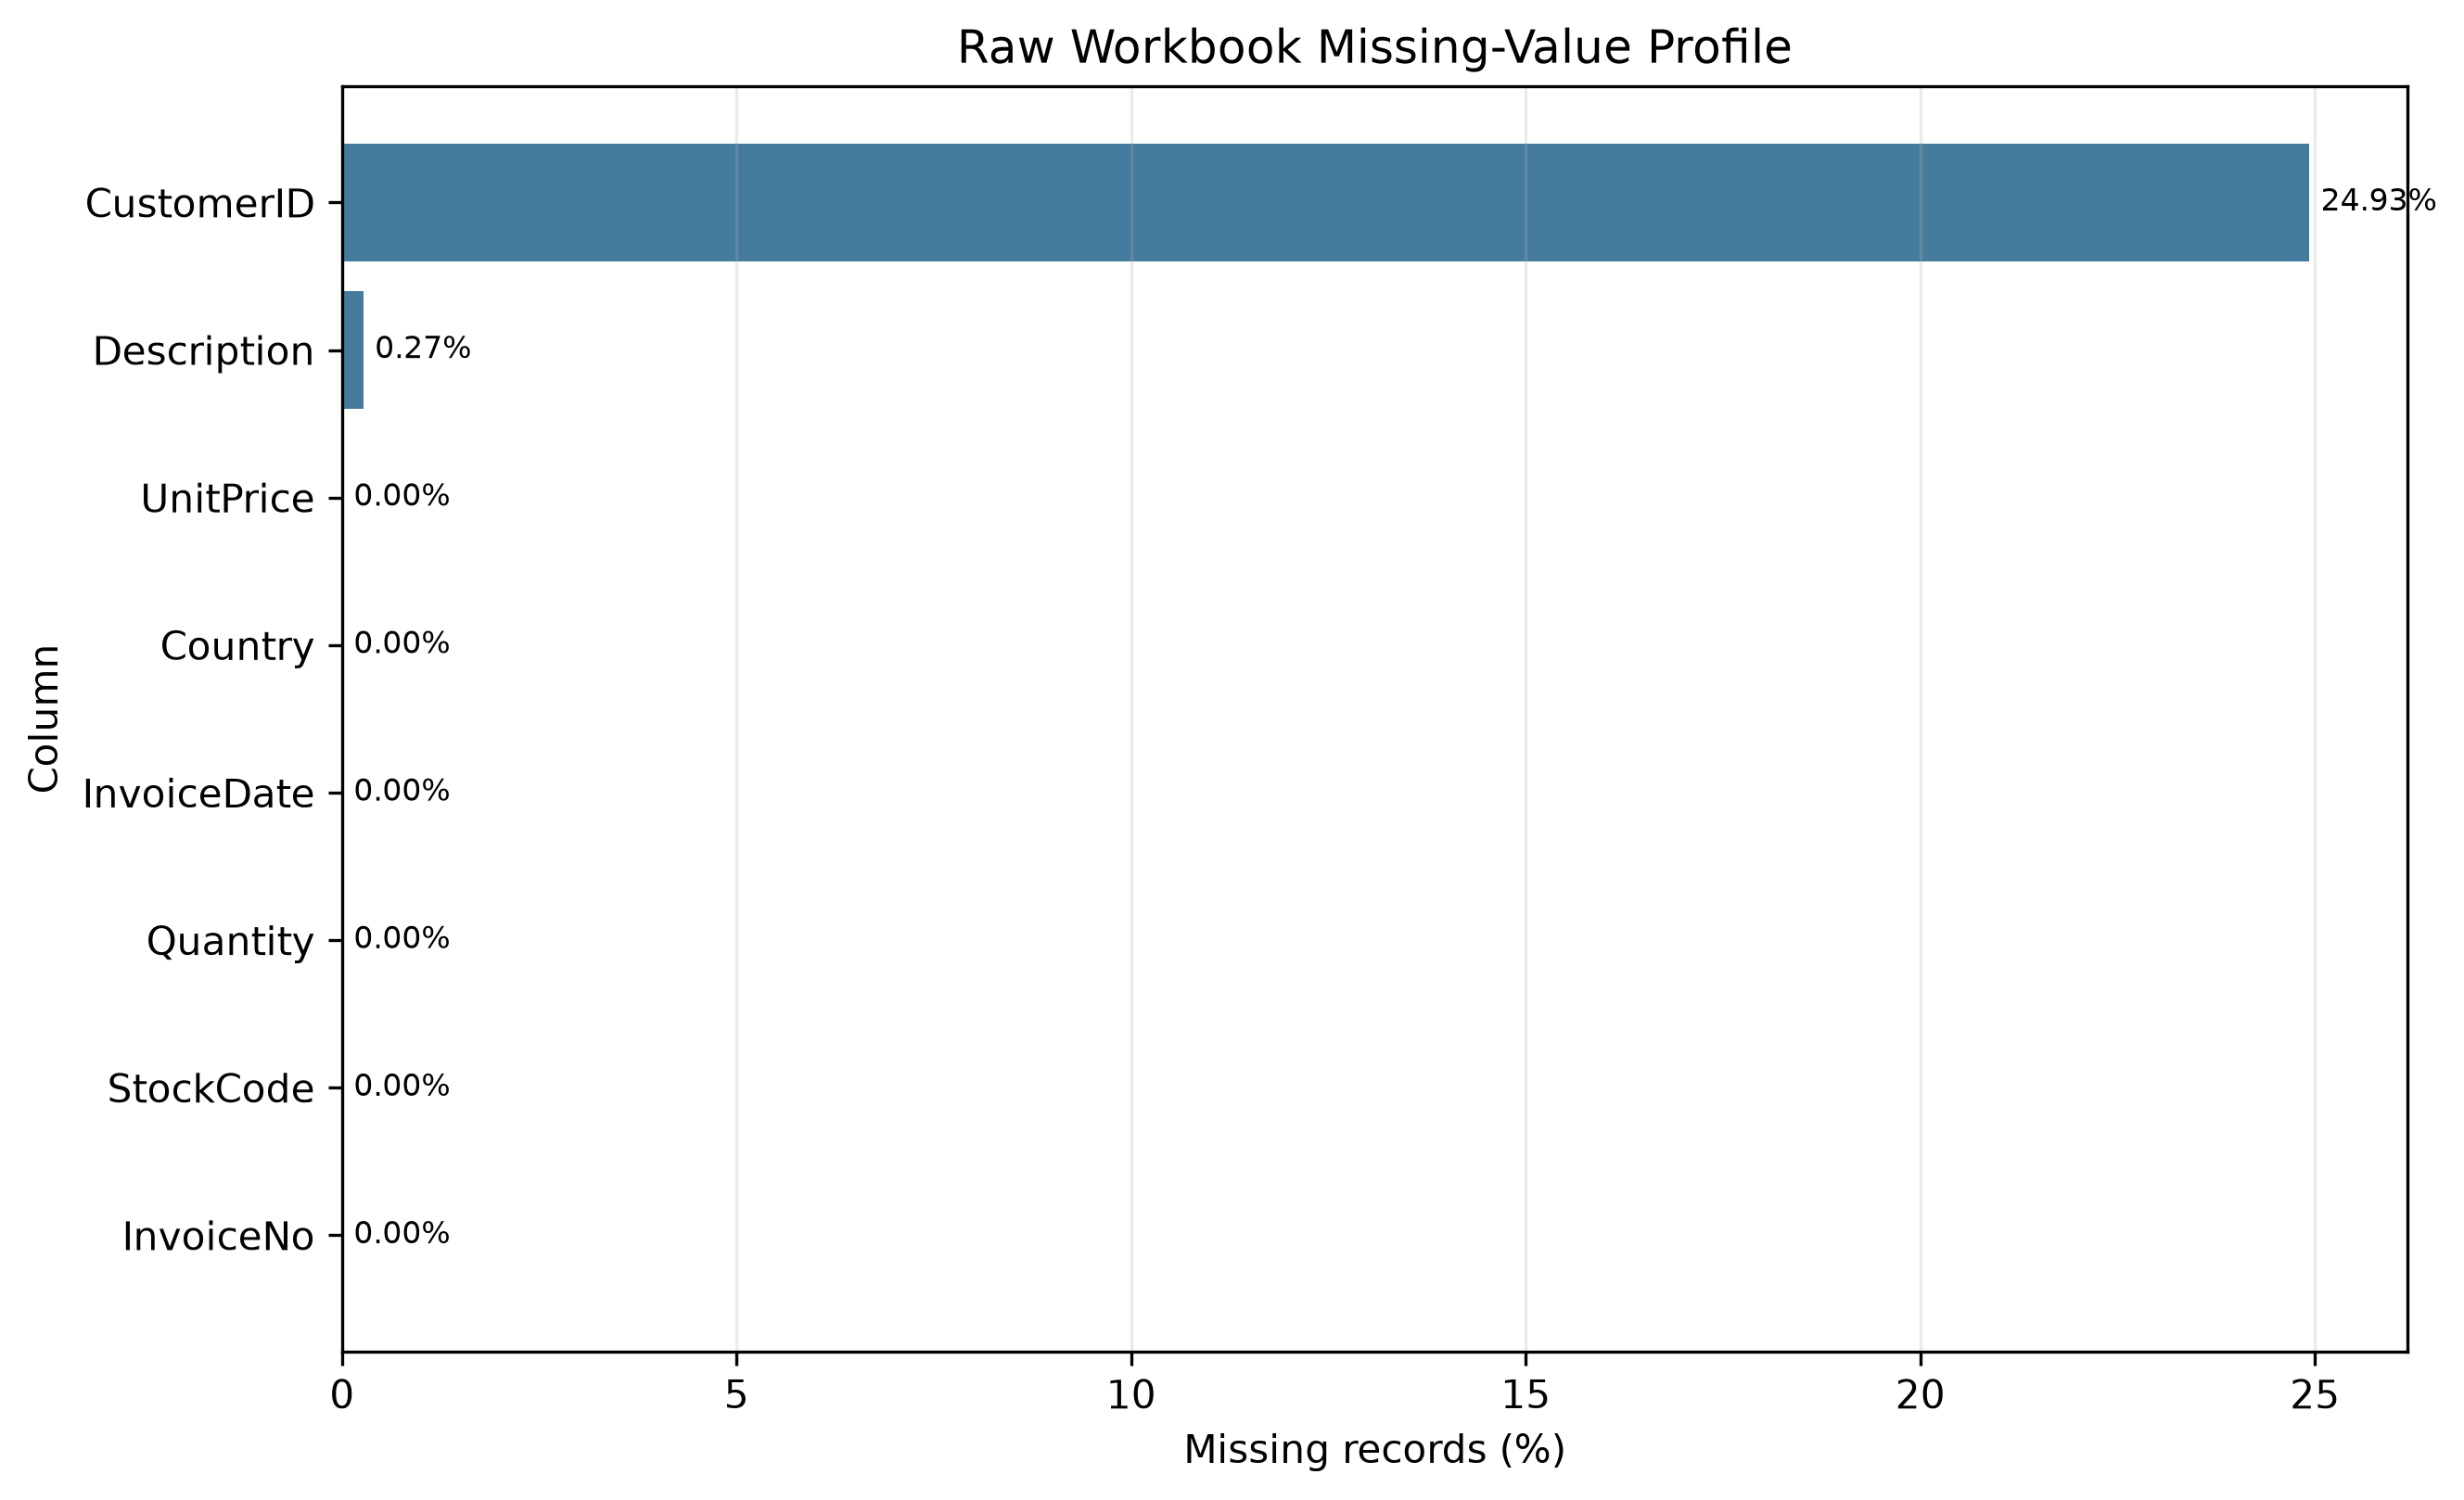

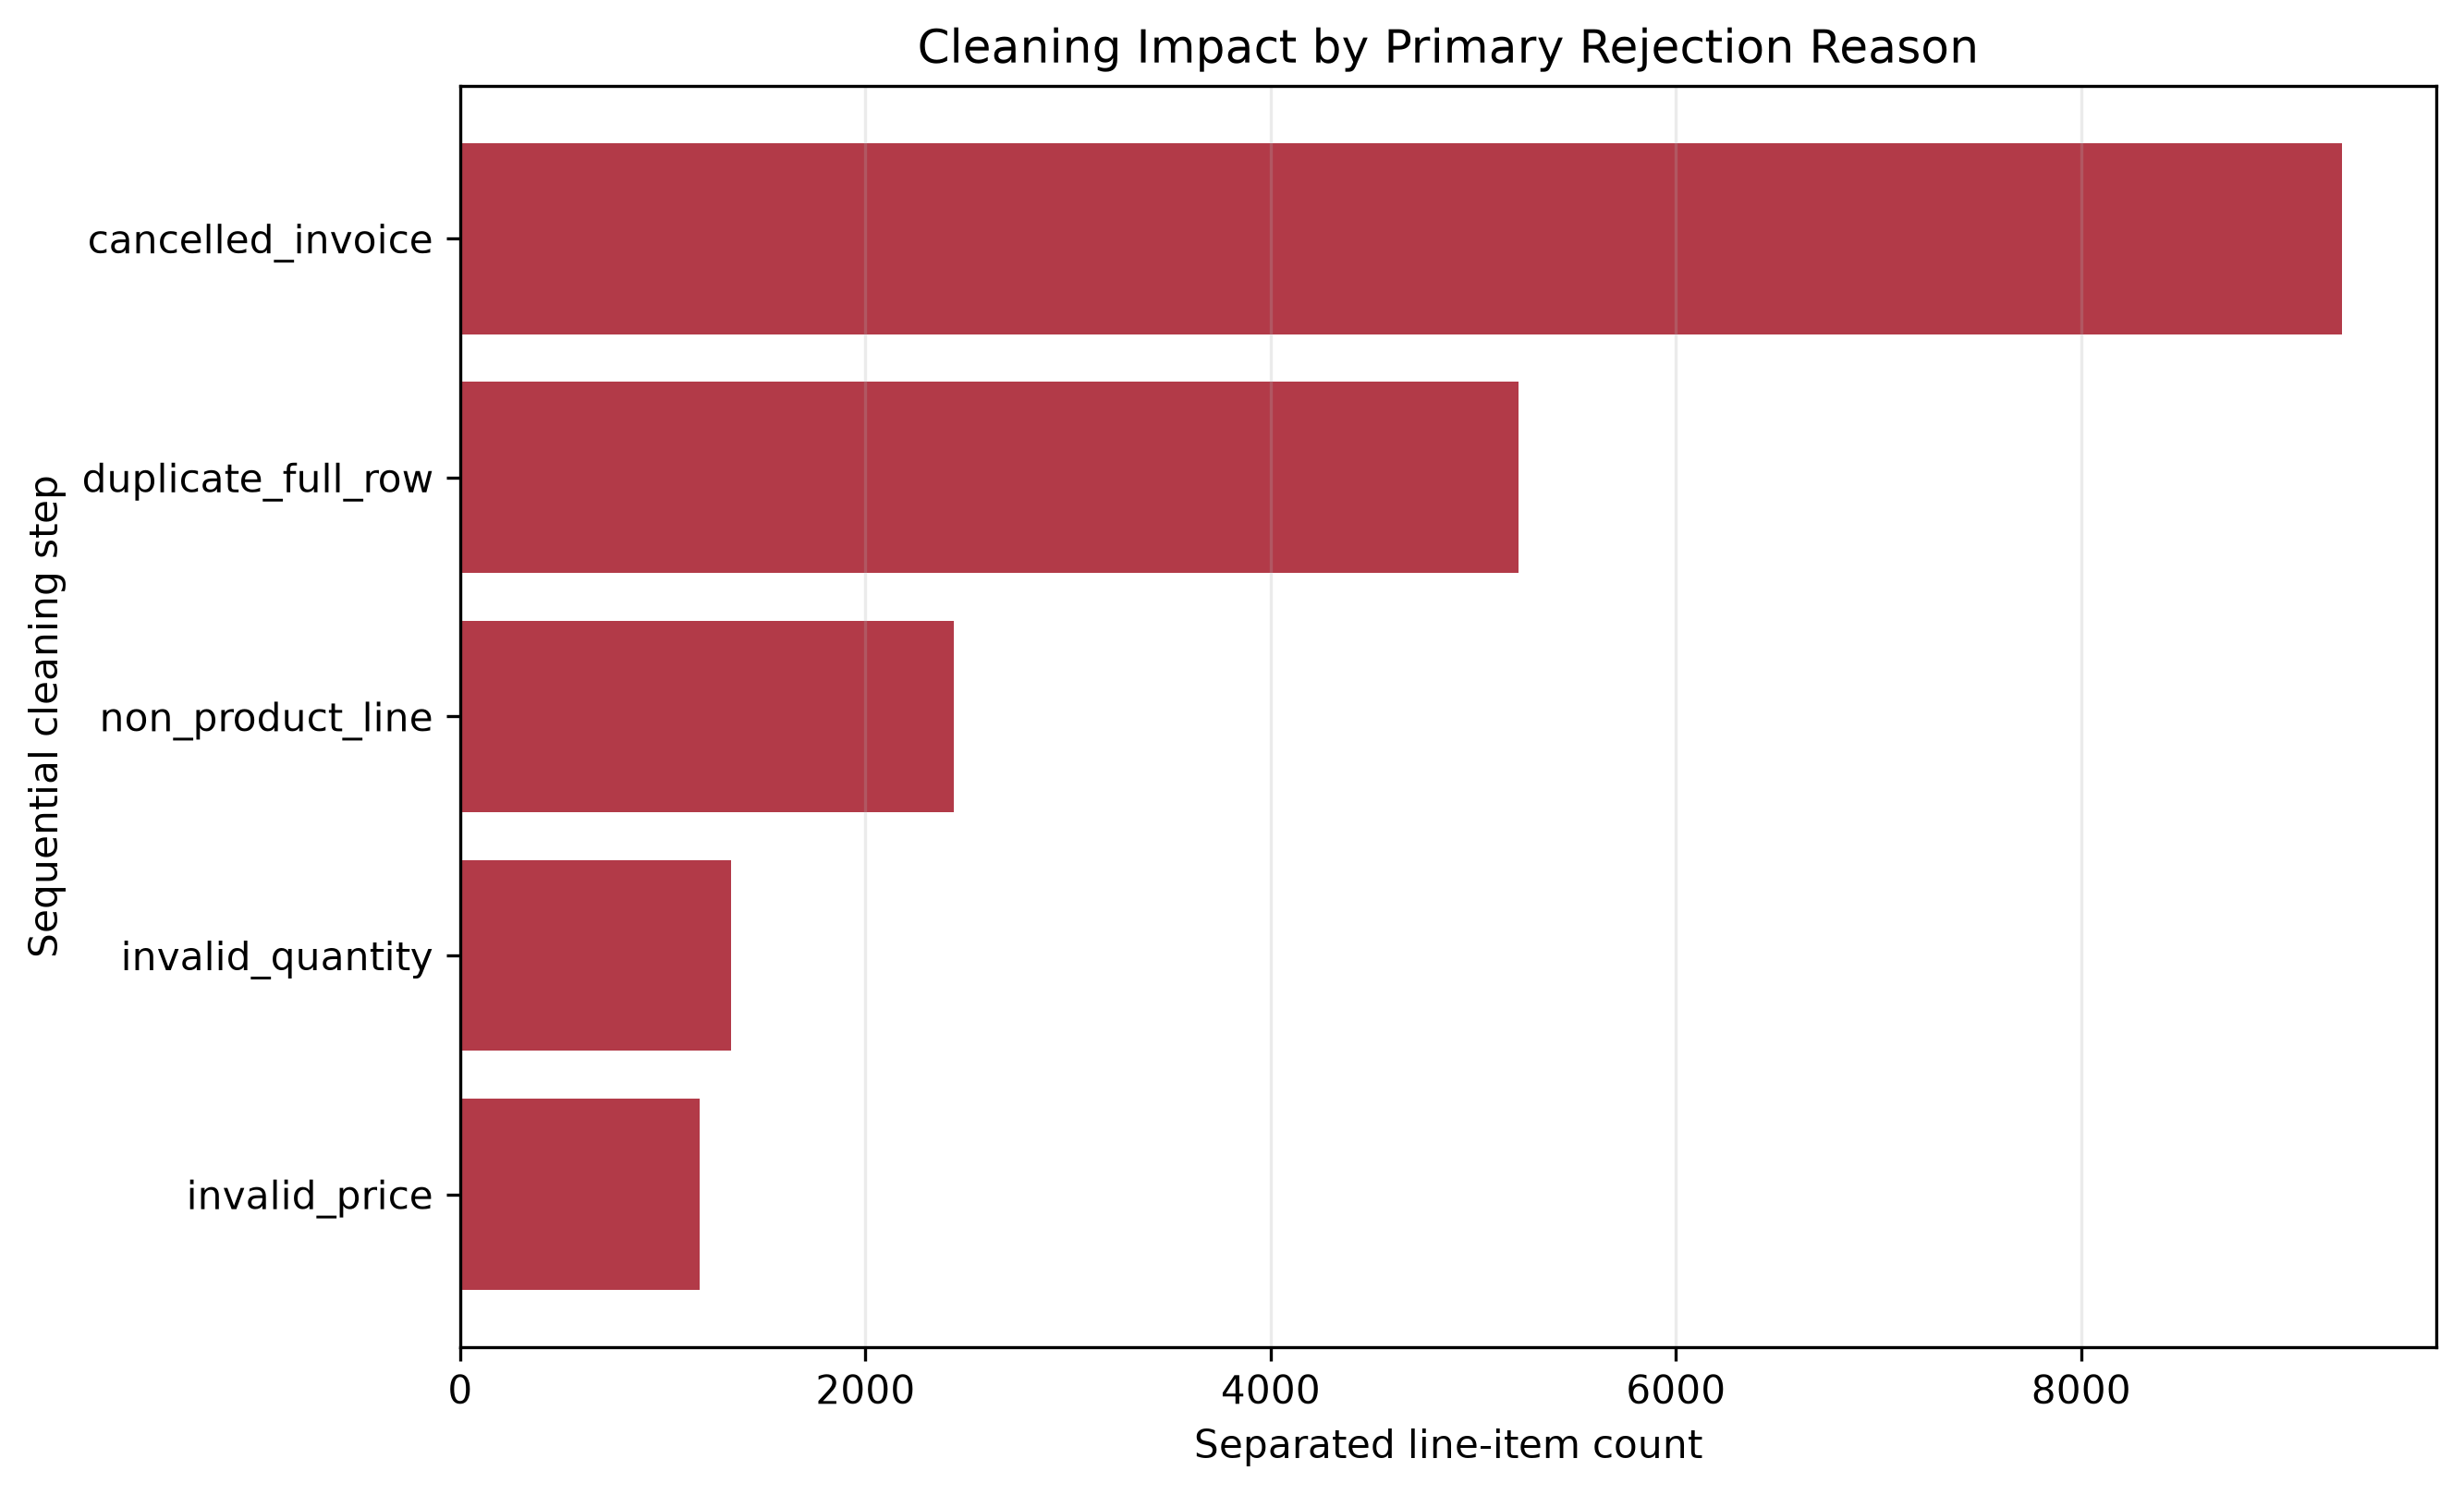

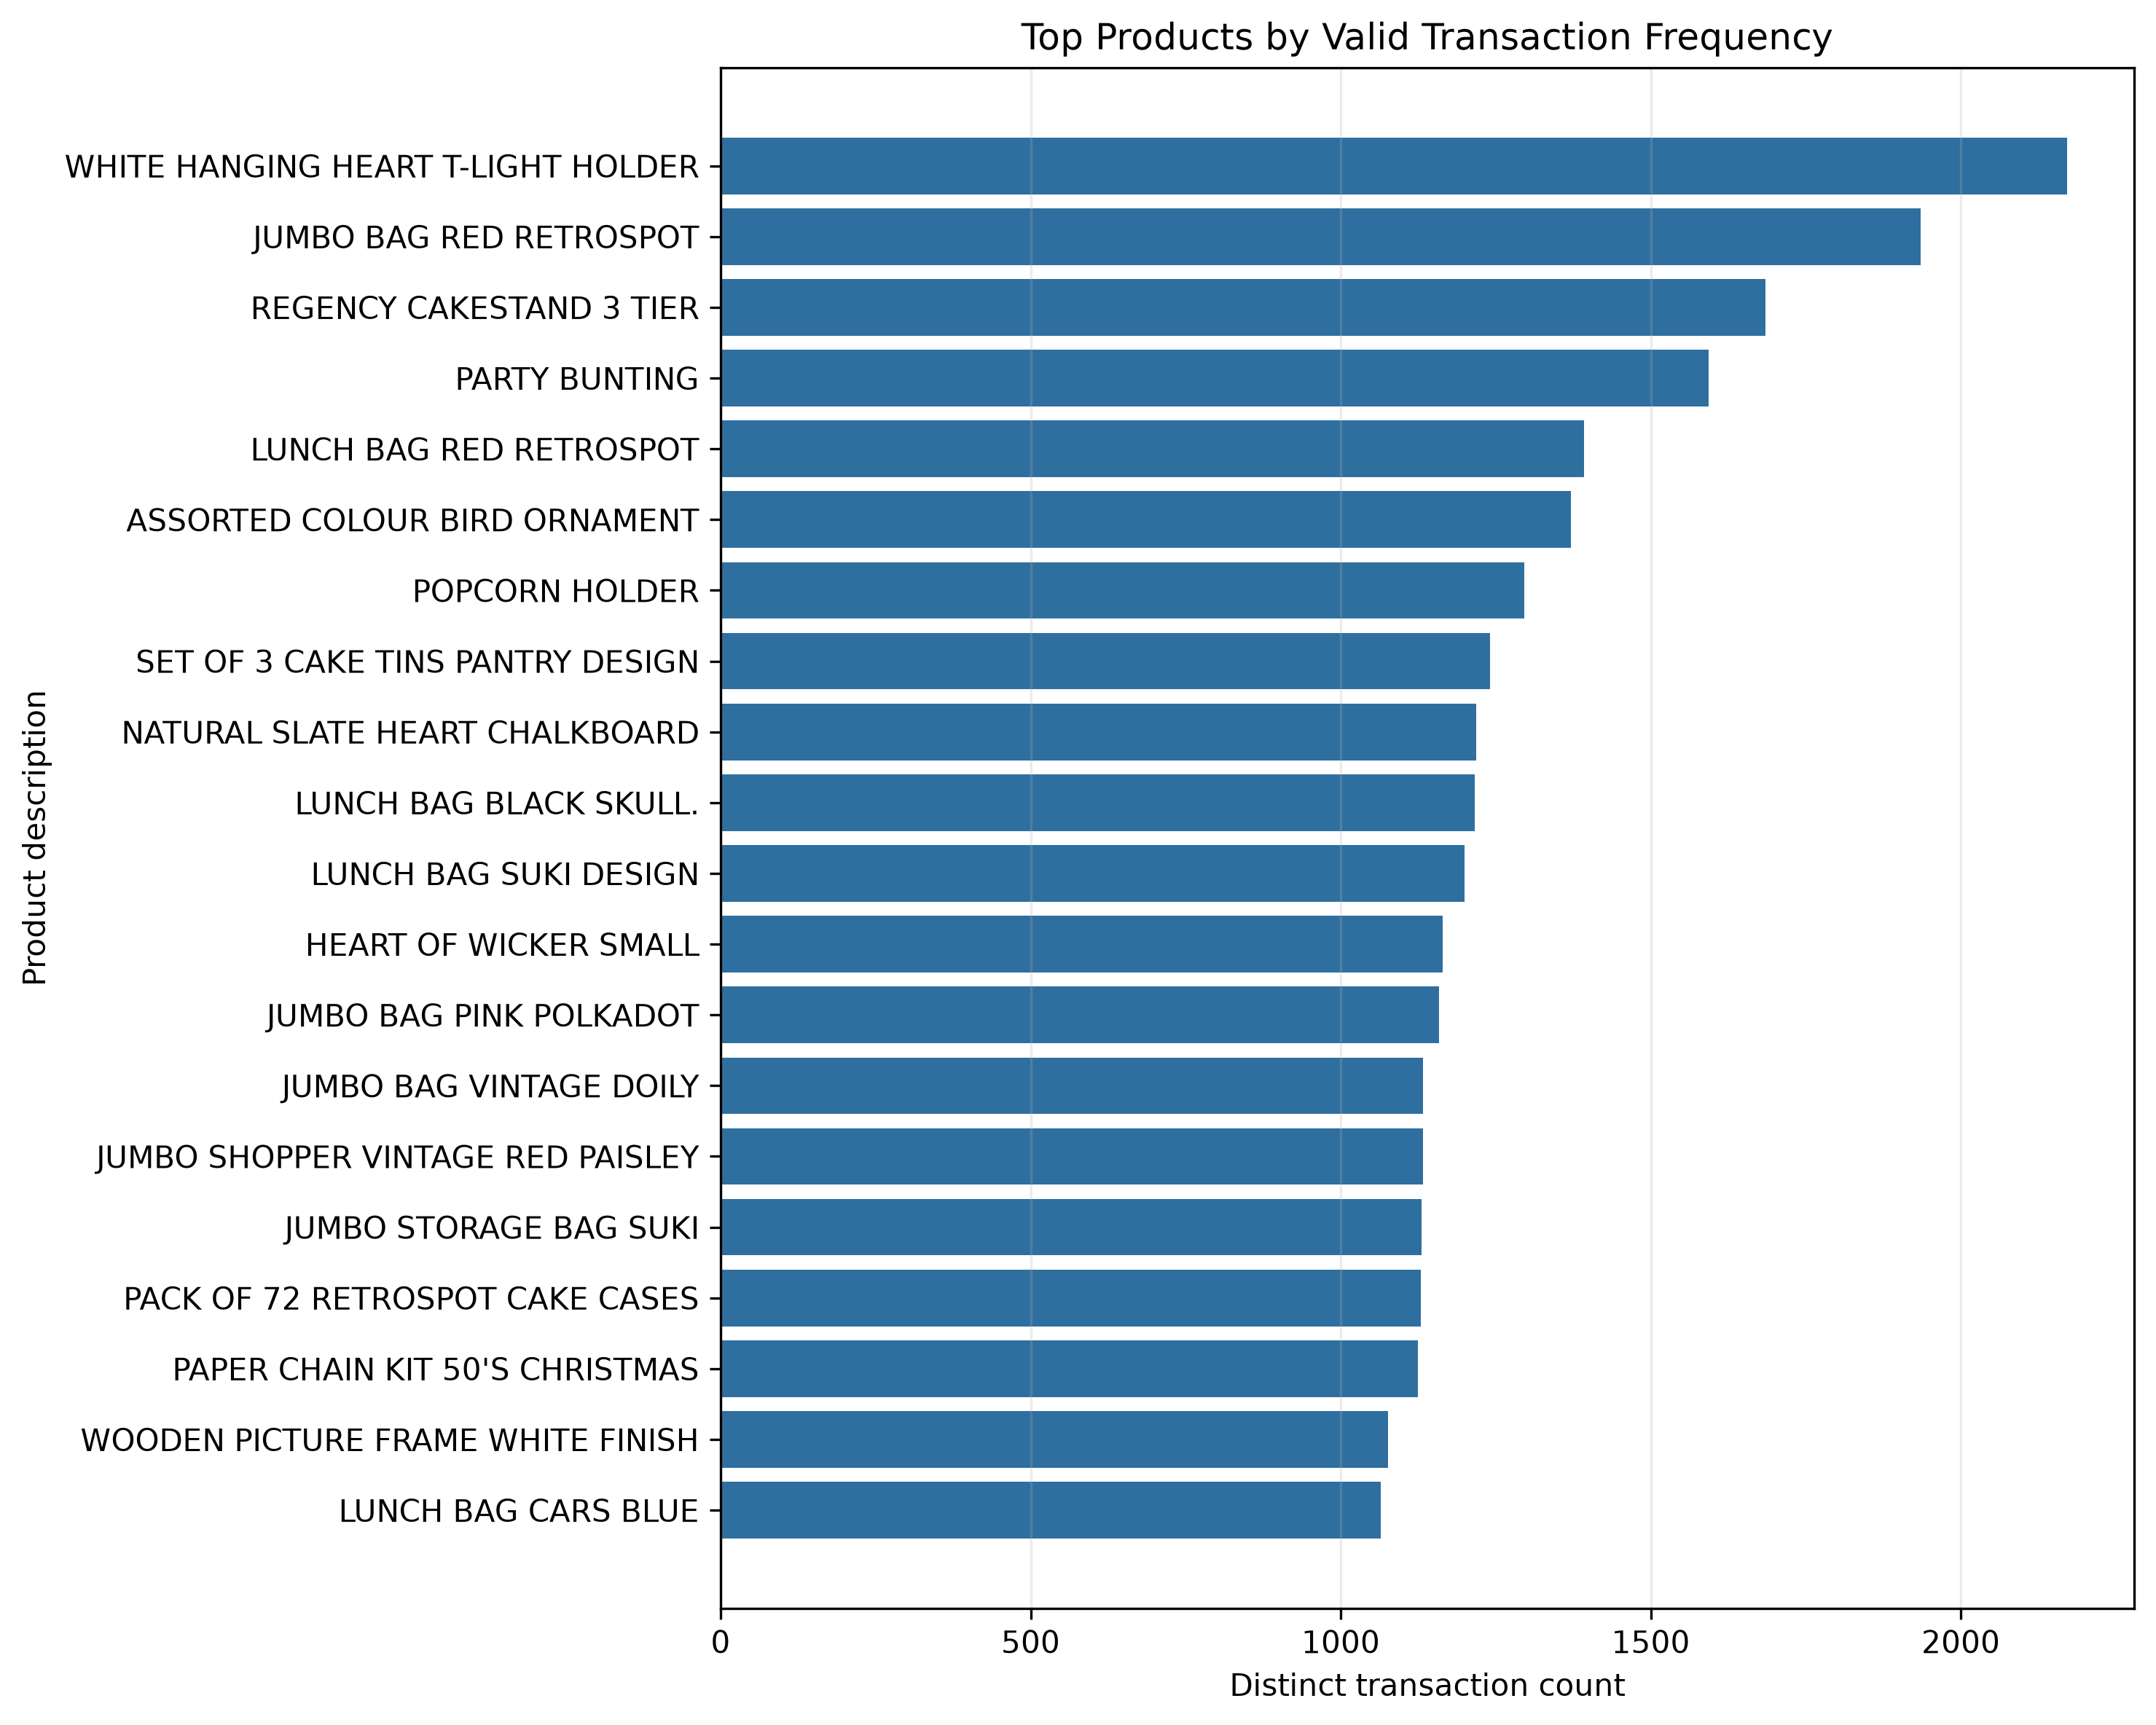

In [9]:
for figure_name in [
    "raw_missing_value_profile.png",
    "cleaning_impact_by_rejection_reason.png",
    "top_products_by_transaction_frequency.png",
]:
    display(Image(filename=str(project_path("outputs", "figures", figure_name)), width=900))

## 11. الجاهزية للمرحلة التالية

أصبحت البيانات الخام موثقة ببصمة، والسجلات المقبولة والمرفوضة منفصلة، والمعاملات معاد بناؤها، ومصفوفة السلة الثنائية محفوظة بصيغة sparse مع خرائط صفوف وأعمدة مستقرة. هذه النتائج تصف **جودة البيانات وتجهيزها فقط**.

**لم يُنفذ FP-Growth أو Apriori، ولم تُولد Frequent Itemsets أو Association Rules، ولم يُجر تحليل WEKA.**